# TP : Introduction à YOLO et au Format de Données pour la Détection d'Objets

Ce TP vous permettra de découvrir le format de données utilisé par YOLO (You Only Look Once), une architecture de deep learning très populaire pour la détection d'objets en temps réel.

Vous apprendrez à manipuler le dataset COCO8, une version miniature du célèbre dataset COCO, et à comprendre comment les bounding boxes sont représentées au format YOLO.

Vous utiliserez la bibliothèque Ultralytics pour charger un modèle YOLO pré-entraîné et effectuer des prédictions.

L'objectif est de vous familiariser avec la structure des données d'entraînement, le format des annotations, et l'exploitation des résultats de détection, compétences essentielles avant d'aborder l'entraînement de vos propres modèles de détection d'objets.

### Installer la bibliothèque Ultralytics

Pour ce TP, vous aurez besoin de la bibliothèque Ultralytics qui fournit une implémentation moderne et simple d'utilisation de YOLO.

Installez cette bibliothèque en utilisant `pip` avec la commande appropriée.

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.6 MB/s eta 0:00:00


# Etude d'un Dataset YOLO

### Télécharger et extraire le dataset COCO8

Le dataset COCO8 est une version réduite du célèbre dataset COCO (Common Objects in Context), spécialement conçue pour des tests rapides et l'apprentissage avec YOLO.

Il contient :
- 8 images d'entraînement et 8 images de validation
- Des annotations au format YOLO avec des bounding boxes
- 80 classes d'objets du quotidien (personnes, véhicules, animaux, etc.)

In [4]:
import os
import urllib.request
import zipfile

# Téléchargement du dataset coco8
# YOLO('yolo11n.pt')  # Initialize model to trigger dataset download if needed

# Download coco8 dataset
url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip"
zip_path = "coco8.zip"

print("Téléchargement du dataset coco8...")
urllib.request.urlretrieve(url, zip_path)

print("Extraction du dataset...")
data_dir = './' # TODO: spécifiez le chemin du répertoire où extraire les données
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

# Nettoyage du fichier zip
os.remove(zip_path)

print("Dataset coco8 téléchargé et extrait avec succès!")

Téléchargement du dataset coco8...
Extraction du dataset...
Dataset coco8 téléchargé et extrait avec succès!


### Importer les bibliothèques nécessaires

Importez les bibliothèques qui seront utilisées tout au long de ce TP :
- `os` pour la manipulation des chemins de fichiers
- `glob` pour rechercher des fichiers selon des motifs
- `cv2` (OpenCV) pour la lecture et la manipulation d'images
- `matplotlib.pyplot` pour la visualisation
- `yaml` pour lire les fichiers de configuration au format YAML
- `YOLO` depuis le module `ultralytics` pour charger et utiliser les modèles YOLO

In [5]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import yaml
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Charger et afficher la configuration du dataset

Les datasets YOLO utilisent un fichier de configuration au format YAML qui définit la structure du dataset.

Le YAML pour coco8 est disponible sur le [github d'Ultralytics](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco8.yaml).

**!!! ATTENTION : il faut l'adapter à votre arborescence de fichiers !!!**
- Chargez le fichier `coco8.yaml` et mettez-le dans le répertoire courant.
- Editez-le pour l'adapter à votre arborescence : édition du `path`.
- Chargez ses données dans une variable `yaml_data`en utilisant la bibliothèque `yaml`.
- Affichez le contenu complet de cette configuration pour comprendre sa structure.

In [11]:
yaml_path = "./coco8.yaml"
with open(yaml_path, 'r', encoding='utf-8') as f:
    yaml_data = yaml.safe_load(f)

display(yaml_data)

{'path': 'coco8',
 'train': 'images/train',
 'val': 'images/val',
 'test': None,
 'names': {0: 'person',
  1: 'bicycle',
  2: 'car',
  3: 'motorcycle',
  4: 'airplane',
  5: 'bus',
  6: 'train',
  7: 'truck',
  8: 'boat',
  9: 'traffic light',
  10: 'fire hydrant',
  11: 'stop sign',
  12: 'parking meter',
  13: 'bench',
  14: 'bird',
  15: 'cat',
  16: 'dog',
  17: 'horse',
  18: 'sheep',
  19: 'cow',
  20: 'elephant',
  21: 'bear',
  22: 'zebra',
  23: 'giraffe',
  24: 'backpack',
  25: 'umbrella',
  26: 'handbag',
  27: 'tie',
  28: 'suitcase',
  29: 'frisbee',
  30: 'skis',
  31: 'snowboard',
  32: 'sports ball',
  33: 'kite',
  34: 'baseball bat',
  35: 'baseball glove',
  36: 'skateboard',
  37: 'surfboard',
  38: 'tennis racket',
  39: 'bottle',
  40: 'wine glass',
  41: 'cup',
  42: 'fork',
  43: 'knife',
  44: 'spoon',
  45: 'bowl',
  46: 'banana',
  47: 'apple',
  48: 'sandwich',
  49: 'orange',
  50: 'broccoli',
  51: 'carrot',
  52: 'hot dog',
  53: 'pizza',
  54: 'donut',


### Extraire les chemins des ensembles de données

À partir du dictionnaire chargé depuis le fichier YAML, extrayez les informations relatives aux chemins des données :
- Le chemin racine du dataset (clé `'path'`)
- Le chemin relatif vers les images d'entraînement (clé `'train'`)
- Le chemin relatif vers les images de validation (clé `'val'`)
- Le chemin relatif vers les images de test (clé `'test'`, qui peut être absent)

Utilisez la méthode `get()` pour gérer l'absence éventuelle de la clé `'test'`. Affichez ces chemins pour vérifier leur extraction.

In [15]:
data_path = yaml_data['path']
images_train_path = f"{yaml_data['train']}"
images_val_path = f"{yaml_data['val']}"
images_test_path = yaml_data.get('test', None) # utiliser get pour éviter une erreur si 'test' n'existe pas
print(f"Dossier racine : {data_path}")
print(f"Dossier images train : {images_train_path}")
print(f"Dossier images val : {images_val_path}")
print(f"Dossier images test : {images_test_path}")

Dossier racine : coco8
Dossier images train : images/train
Dossier images val : images/val
Dossier images test : None


### Extraire le dictionnaire des classes

Le fichier YAML contient également un dictionnaire associant chaque identifiant de classe (entier) à son nom textuel (chaîne de caractères).

Extrayez ce dictionnaire depuis la clé `'names'` du fichier de configuration chargé précédemment et mettez le dans la variable `class_id_names`.

In [14]:
class_id_names =yaml_data['names']
display(class_id_names)

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

### Lister les fichiers d'images disponibles

Utilisez la fonction `glob.glob()` pour rechercher tous les fichiers d'images au format JPEG dans les dossiers d'entraînement et de validation.

Construisez les chemins de recherche en combinant :
- Le chemin racine du dataset (`data_path`)
- Les chemins relatifs extraits précédemment (`images_train_path` et `images_val_path`)
- Le motif `"*.jpg"` pour sélectionner uniquement les fichiers JPEG

Stockez les listes de fichiers trouvés dans des variables distinctes (`train_image_files` et `valid_image_files`) pour l'entraînement et la validation.

Affichez ensuite :
- Le nombre d'images dans chaque ensemble
- Les 5 premiers chemins de fichiers de chaque liste pour vérification

In [20]:
train_image_files = glob.glob(f"{data_path}/{images_train_path}/*.jpg")
valid_image_files = glob.glob(f"{data_path}/{images_val_path}/*.jpg")
print(f"Images train ({len(train_image_files)}) : {train_image_files[:5]} ...")
print(f"Images valid ({len(valid_image_files)}) : {valid_image_files[:5]} ...")

Images train (4) : ['coco8/images/train/000000000034.jpg', 'coco8/images/train/000000000009.jpg', 'coco8/images/train/000000000025.jpg', 'coco8/images/train/000000000030.jpg'] ...
Images valid (4) : ['coco8/images/val/000000000061.jpg', 'coco8/images/val/000000000042.jpg', 'coco8/images/val/000000000049.jpg', 'coco8/images/val/000000000036.jpg'] ...


### Charger et afficher une image d'entraînement

Implémentez le code permettant de charger et visualiser une image du dataset :
- Sélectionnez une image spécifique dans la liste `train_image_files` (ici l'indice 2)
- Chargez cette image avec `cv2.imread()` et stockez-la dans une variable `image`
- Récupérez ses dimensions (largeur et hauteur) depuis la shape de l'image
- Affichez le chemin complet du fichier ainsi que ses dimensions
- Visualisez l'image avec `matplotlib`

Image path : coco8/images/train/000000000025.jpg
Width : 640 ; Height : 426


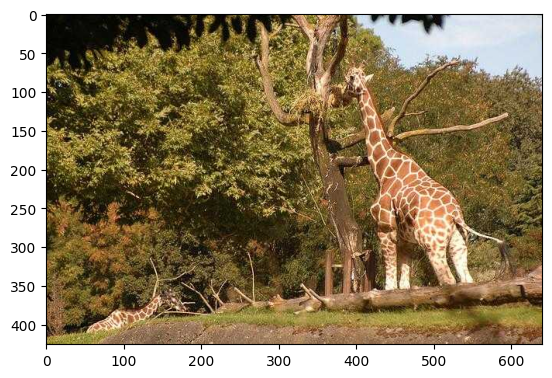

In [21]:
num = 2

image_file = train_image_files[num]
print(f"Image path : {image_file}")
image = cv2.imread(image_file)

image_height, image_width, _ = image.shape
print(f"Width : {image_width} ; Height : {image_height}")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

### Lire et parser les annotations au format YOLO

**Format des annotations YOLO :**

Les annotations au format YOLO sont stockées dans des fichiers texte avec les caractéristiques suivantes :
- Même nom que l'image mais avec extension `.txt` au lieu de `.jpg`
- Situés dans un dossier `labels` au lieu de `images`
- Chaque ligne correspond à un objet détecté
- 5 valeurs par ligne séparées par des espaces : `class_id x_center y_center width height`
- Toutes les coordonnées sont normalisées entre 0 et 1 (pourcentages de la taille de l'image)

**Implémentation du parser :**

Créez un script pour lire et parser les annotations de l'image précédemment chargée :
- Construisez le chemin du fichier d'annotations en remplaçant `"images"` par `"labels"` et `".jpg"` par `".txt"` dans `image_file`
- Initialisez deux listes vides : `boxes` pour les bounding boxes et `classes` pour les identifiants de classe
- Lisez toutes les lignes du fichier d'annotations
    - Pour chaque ligne, extrayez les 5 valeurs et convertissez-les aux types appropriés (entier pour `class_id`, flottants pour les coordonnées)
    - Stockez `[x_center, y_center, width, height]` dans la liste `boxes` et `class_id` dans la liste `classes`
    - Affichez pour chaque objet son nom de classe et ses coordonnées normalisées

In [23]:
boxes = [] # récupération des bounding boxes
classes = [] # récupération des classes correspondantes

label_file = image_file.replace("images", "labels").replace(".jpg", ".txt")
print(label_file)

with open(label_file, 'r') as f:
    lines = f.readlines()

for line in lines:
    print("-" * 50)
    parts = line.strip().split()
    if len(parts) == 5:
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        print(f"Box class : {class_id_names[class_id]}") # TODO
        print(f"Valeurs lues : {[x_center, y_center, width, height]}")

        boxes.append([x_center, y_center, width, height])
        classes.append(class_id)


coco8/labels/train/000000000025.txt
--------------------------------------------------
Box class : giraffe
Valeurs lues : [0.770336, 0.489695, 0.335891, 0.697559]
--------------------------------------------------
Box class : giraffe
Valeurs lues : [0.185977, 0.901608, 0.206297, 0.129554]


### Implémenter une fonction de visualisation des bounding boxes

Implémentez la fonction `show_yolo_boxes(image, boxes, descs)` permettant d'afficher une image avec ses bounding boxes superposées. Cette fonction prend en paramètres :
- `image` : un array NumPy représentant l'image au format RGB
- `boxes` : une liste de bounding boxes au format YOLO normalisé `[x_center, y_center, width, height]` avec des valeurs entre 0 et 1
- `descs` : une liste de chaînes de caractères décrivant chaque bounding box (nom de classe ou autre description)

La fonction doit :
- Créer une figure matplotlib
- Pour chaque bounding box :
    - effectuer la dénormalisation des coordonnées en multipliant par les dimensions de l'image
    - convertir du format centre-largeur-hauteur vers le format coin supérieur gauche-largeur-hauteur (nécessaire pour `plt.Rectangle`)
    - Dessiner chaque rectangle avec `plt.Rectangle()` sans remplissage, avec un contour vert (lime) et une épaisseur de ligne de 2 pixels
    - Afficher la description de chaque bounding box avec `plt.text()` au-dessus du rectangle, en utilisant une couleur lime sur fond noir semi-transparent pour la lisibilité

NB : vous pouvez tester la fonction avec la cellule suivante....

In [46]:
def show_yolo_boxes(image, boxes, descs):
    """
    Display an image with YOLO format bounding boxes and descriptions.

    Args:
        image: numpy array representing the image (zRGB format)
        boxes: list of bounding boxes in YOLO normalized format [x_center, y_center, width, height]
               where values are normalized between 0 and 1
        descs: list of description strings for each bounding box
    """

    # Afficher l'image avec les bounding boxes et les classes
    plt.figure(figsize=(8, 8))
    plt.imshow(image)

    image_height, image_width,  _ = image.shape

    # Dessiner chaque bounding box avec sa description

    for i in range(len(boxes)):
        x, y, w, h = boxes[i]

        # Dénormalisation
        w = w*image_width
        h = h*image_height
        x = x*image_width-w//2
        y = y*image_height-h//2

        # Dessiner le rectangle
        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='lime', linewidth=2)
        plt.gca().add_patch(rect)

        # Ajouter la decription
        plt.text(x + 3, y - 10, descs[i],
                color='lime', fontsize=12,
                bbox=dict(facecolor='black', alpha=0.7, edgecolor='lime'))

    # plt.axis('off')
    plt.show()

[[0.770336, 0.489695, 0.335891, 0.697559], [0.185977, 0.901608, 0.206297, 0.129554]] ['giraffe', 'giraffe'] 426 640


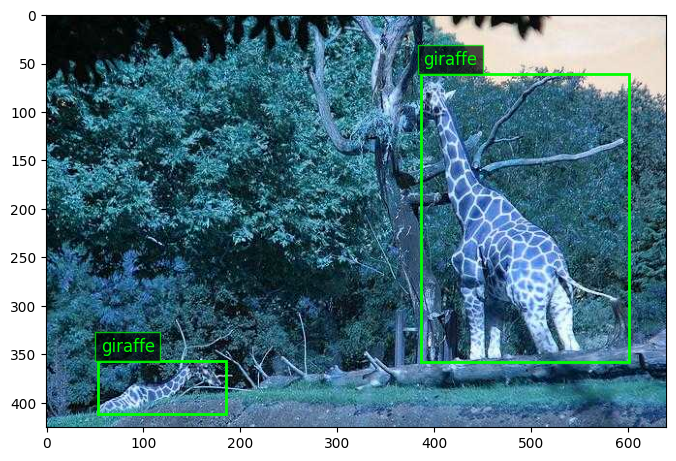

In [45]:
descriptions = [class_id_names.get(class_id, 'Unknown') for class_id in classes]
show_yolo_boxes(image=image, boxes=boxes, descs=descriptions)

## Prédictions avec un Modèle Pré-entrainé

### Charger un modèle YOLO pré-entraîné

La bibliothèque Ultralytics fournit une API simple pour charger et utiliser des modèles YOLO pré-entraînés.

- Instanciez un modèle YOLO dans une variable `model` en chargeant les poids pré-entraînés depuis le fichier `"yolo11n.pt"` (variante nano de YOLO11, légère et rapide).

In [47]:
model = YOLO("yolo11n.pt")

### Afficher la liste des classes détectables

Les modèles YOLO sont entraînés pour détecter un ensemble spécifique de classes d'objets, dont la liste est disponible dans l'attribut `names`.

Cette information est essentielle pour interpréter les résultats de détection du modèle.

Parcourez ce dictionnaire et affichez pour chaque classe son identifiant numérique suivi de son nom textuel.

NB : ce modèle ayant été pré-entrainé à partir d'un fichier YAML identique (à part le `path`) au notre chargé précédemment, la liste des classes traitées par le modèle est (normalement) identique.

In [48]:
print("Liste des classes détectées par le modèle:")
for cls in model.names:
    print(f"{cls} : {class_id_names[cls]}")

Liste des classes détectées par le modèle:
0 : person
1 : bicycle
2 : car
3 : motorcycle
4 : airplane
5 : bus
6 : train
7 : truck
8 : boat
9 : traffic light
10 : fire hydrant
11 : stop sign
12 : parking meter
13 : bench
14 : bird
15 : cat
16 : dog
17 : horse
18 : sheep
19 : cow
20 : elephant
21 : bear
22 : zebra
23 : giraffe
24 : backpack
25 : umbrella
26 : handbag
27 : tie
28 : suitcase
29 : frisbee
30 : skis
31 : snowboard
32 : sports ball
33 : kite
34 : baseball bat
35 : baseball glove
36 : skateboard
37 : surfboard
38 : tennis racket
39 : bottle
40 : wine glass
41 : cup
42 : fork
43 : knife
44 : spoon
45 : bowl
46 : banana
47 : apple
48 : sandwich
49 : orange
50 : broccoli
51 : carrot
52 : hot dog
53 : pizza
54 : donut
55 : cake
56 : chair
57 : couch
58 : potted plant
59 : bed
60 : dining table
61 : toilet
62 : tv
63 : laptop
64 : mouse
65 : remote
66 : keyboard
67 : cell phone
68 : microwave
69 : oven
70 : toaster
71 : sink
72 : refrigerator
73 : book
74 : clock
75 : vase
76 : sci

### Effectuer des prédictions sur les images de validation

Le modèle YOLO peut accepter directement une liste de chemins de fichiers en paramètre et retourne un objet contenant les résultats de détection pour chaque image.

Appelez le modèle avec la liste des fichiers d'images de validation et stockez les résultats dans une variable `results`.

Affichez ensuite l'objet résultats pour observer sa structure.

In [49]:
print(f"Nous allons prédire sur les images de validation ({len(valid_image_files)}): {valid_image_files}")

Nous allons prédire sur les images de validation (4): ['coco8/images/val/000000000061.jpg', 'coco8/images/val/000000000042.jpg', 'coco8/images/val/000000000049.jpg', 'coco8/images/val/000000000036.jpg']


In [50]:
results =model(valid_image_files)
print(results)


0: 640x640 2 elephants, 17.3ms
1: 640x640 1 dog, 1 suitcase, 17.3ms
2: 640x640 6 persons, 2 horses, 17.3ms
3: 640x640 1 person, 1 umbrella, 17.3ms
Speed: 4.0ms preprocess, 17.3ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 

### Inspecter le type des résultats

Les résultats retournés par le modèle YOLO sont stockés dans une liste où chaque élément correspond aux détections d'une image.

Affichez le type du premier élément de cette liste pour comprendre la structure de données utilisée par Ultralytics pour représenter les résultats de détection.

In [51]:
num = 0
print(f'Type des résultats : {type(results[num])}')

Type des résultats : <class 'ultralytics.engine.results.Results'>


### Implémenter une fonction de visualisation des détections

Pour exploiter les résultats de détection fournis par le modèle YOLO, implémentez la fonction `show_detection_result(result)` qui prend en paramètre un objet résultat individuel (de type `ultralytics.engine.results.Results`, cf. [documentation](https://docs.ultralytics.com/reference/engine/results/#ultralytics.engine.results.Results)) et visualise les détections sur l'image correspondante.

La fonction doit :
- Extraire l'image d'origine depuis l'attribut `orig_img` du résultat (format array NumPy RGB)
- Extraire les bounding boxes normalisées avec l'attribut `boxes.xywhn` et les convertir en liste Python
- Extraire les identifiants de classe prédits depuis `boxes.cls` et les convertir en entiers
- Extraire les scores de confiance depuis `boxes.conf` et les convertir en flottants
- Générer des descriptions combinant le nom de la classe (via `model.names`) et le score de confiance formaté à deux décimales
- Appeler la fonction `show_yolo_boxes()` précédemment implémentée pour afficher l'image avec les détections

NB: La documentation de la classe `Results` d'Ultralytics est disponible à l'URL : https://docs.ultralytics.com/reference/engine/results/#ultralytics.engine.results.Results

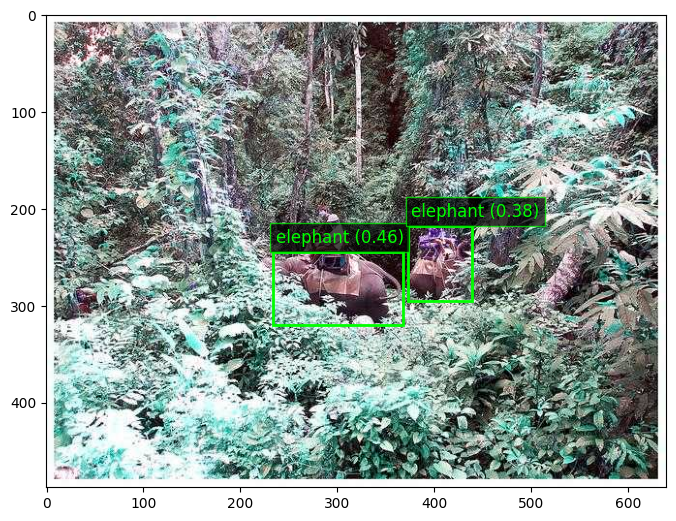

In [60]:
def show_detection_result(result):
    """
    Display detection results on an image.

    Args:
        result: A single result object from YOLO model prediction.
    """
    image = result.orig_img
    boxes = result.boxes
    class_ids = [ int(id) for id in result.boxes.cls] # conversion des id en int
    confs = [float(val) for val in boxes.conf] # conversion des confiances en float
    descs = [ f"{model.names[id]} ({c:.2f})" for (id, c) in list(map(lambda x, y: (x, y), class_ids, confs))] # génération des descriptions avec confiances
    show_yolo_boxes(image, boxes.xywhn.cpu(), descs)

# test de la fonction
show_detection_result(results[num])

### Utiliser la méthode de visualisation native d'Ultralytics

La bibliothèque Ultralytics fournit également une méthode `.show()` directement sur les objets résultats pour visualiser rapidement les détections.

Appelez cette méthode sur le même résultat pour afficher l'image avec les bounding boxes et les labels.

NB : Ok c'est plus simple, mais il est important de comprendre le format des résultats pour les prochains TPs :) !

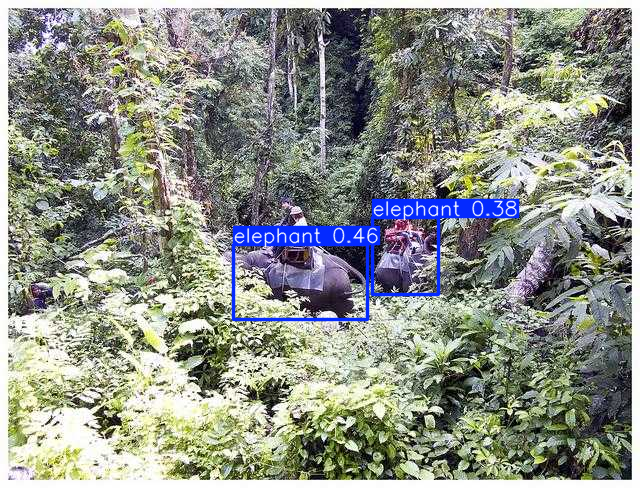

In [61]:
results[num].show()  # Ok c'est plus simple, mais il est important de comprendre le format des résultats pour les prochains TPs :) !

### N'hésitez pas à tester sur les autres images (ou les votres)

In [62]:
for i in range(len(results)):
  results[i].show()

Output hidden; open in https://colab.research.google.com to view.

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
